<a href="https://colab.research.google.com/github/GeorgeGlennon/Part-II-Chemistry-Programming/blob/Exercise-3/Exercise_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
def retrieve_data(file_path):

  """A General function that retrieves rate constants and initial concentrations from a .txt file"""

  concentrations = {}
  rates = {}
  concentrationlines = False
  ratelines = False
  with open(file_path, 'r') as file:
    lines = file.readlines()
  for line in lines:
    line = line.strip()
    goodline = False
    if line == "Concentrations":
      concentrationlines = True
    elif line == "Rates":
      ratelines = True
      concentrationlines = False
    elif line == "END":
      return concentrations, rates
    elif line == "":
      goodline = False
    else:
      goodline = True
    if goodline == True and concentrationlines == True:
      concentrations.update({line.split()[0]: eval(line.split()[1])})
    if goodline == True and ratelines == True:
      rates.update({line.split()[0]: eval(line.split()[1])})


Please note that the files Oregonator.txt and Protein folding.txt and their respective file paths are essential for the running of the program. The current file paths assume the the two .txt files have been uploaded to the colab session storage.

Convergence reached after 23998 iterations in 0.4033 seconds.



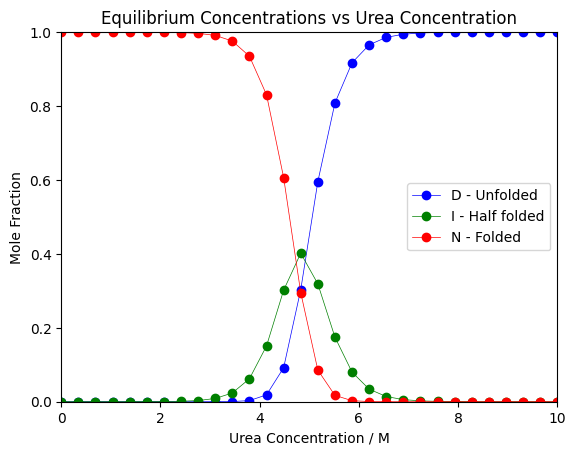

In [24]:
import numpy as np
import numba as nb
import matplotlib.pyplot as plt
import time

class ProteinFoldingSimulator:

    def __init__(self, timestep=6e-6):
        self.concentrations, self.rates = retrieve_data("/content/Protein folding.txt")
        self.timestep = timestep

    @staticmethod
    @nb.njit(fastmath=True)
    def evolve(D, I, N, Kf15, Ku15, Kf16, Ku16, urea, timestep):
        exp_095 = np.exp(0.95 * urea)
        exp_n168 = np.exp(-1.68 * urea)
        exp_n172 = np.exp(-1.72 * urea)
        exp_12 = np.exp(1.2 * urea)

        gradient = 1.0
        n = 0

        while gradient > 1e-6:
            gradI = (-Ku15 * I * exp_095) + (Kf15 * D * exp_n168) + (-Kf16 * I * exp_n172) + (Ku16 * N * exp_12)
            gradD = (-Kf15 * D * exp_n168) + (Ku15 * I * exp_095)
            gradN = (Kf16 * I * exp_n172) + (-Ku16 * N * exp_12)

            D_new = D + gradD * timestep
            I_new = I + gradI * timestep
            N_new = N + gradN * timestep

            gradient = max(abs(gradI), abs(gradD), abs(gradN))

            D, I, N = D_new, I_new, N_new
            n += 1

        return D, I, N, n

    def iterate(self, urea):
        return self.evolve(
            self.concentrations["D"], self.concentrations["I"], self.concentrations["N"], self.rates["Kf15"],
            self.rates["Ku15"], self.rates["Kf16"], self.rates["Ku16"],
            urea, self.timestep
        )

    def run_simulation(self, urea_vals):
        D_vals, I_vals, N_vals = [], [], []
        for urea in urea_vals:
            D, I, N, n = self.iterate(urea)
            D_vals.append(D)
            I_vals.append(I)
            N_vals.append(N)
        return np.array(D_vals), np.array(I_vals), np.array(N_vals), n

    def plot_results(self, urea_vals, D_vals, I_vals, N_vals, n, start_time):
        print(f"Convergence reached after {n} iterations in {time.time() - start_time:.4f} seconds.\n")
        plt.plot(urea_vals, D_vals, linewidth=0.5, marker='o', label="D - Unfolded", color="blue")
        plt.plot(urea_vals, I_vals, linewidth=0.5, marker='o', label="I - Half folded", color="green")
        plt.plot(urea_vals, N_vals, linewidth=0.5, marker='o', label="N - Folded", color="red")
        plt.legend(loc='center right')
        plt.xlim(0, 10)
        plt.ylim(0, 1)
        plt.xlabel("Urea Concentration / M")
        plt.ylabel("Mole Fraction")
        plt.title("Equilibrium Concentrations vs Urea Concentration")
        plt.show()

if __name__ == "__main__":
    start_time = time.time()
    simulator = ProteinFoldingSimulator()
    urea_vals = np.linspace(0, 10, 30)
    D_vals, I_vals, N_vals, n = simulator.run_simulation(urea_vals)
    simulator.plot_results(urea_vals, D_vals, I_vals, N_vals, n, start_time)


This took program 1.3924 seconds to complete 100000000  iterations.



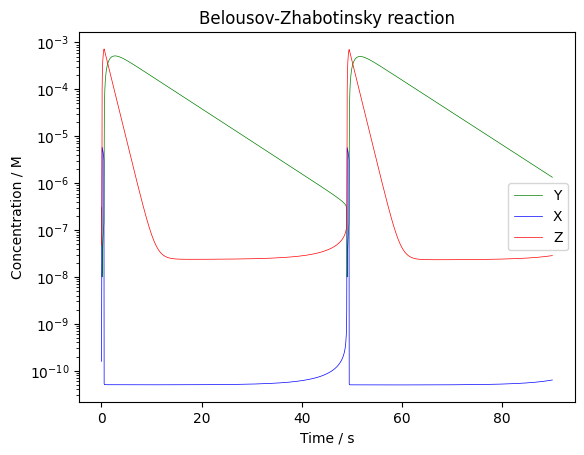

In [26]:
import time
import matplotlib.pyplot as plt
import numpy as np
import numba as nb

class BZSimulator:

    def __init__(self, timestep=1e-6):
        self.concentrations, self.rates = retrieve_data("/content/Oregonator.txt")
        self.timestep = timestep

    @staticmethod
    @nb.njit(fastmath=True)
    def evolve(A, B, P, Q, X, Y, Z, k1, k2, k3, k4, k5, timestep, num_steps, n_vals):

        """A function that increments the concentrations over the specified time step"""

        X_vals, Y_vals, Z_vals = [], [], []
        for n in range(num_steps):
            # Compute gradients
            gradA = -k1 * (A * Y)
            gradY = (-k1 * (A * Y)) + (-k2 * (X * Y)) + (k5 * (Z))
            gradX = k1 * (A * Y) + (-k2 * (X * Y)) + (k3 * (B * X)) + (-2 * k4 * ((X)**2))
            gradB = -k3 * (B * X)
            gradP = k1 * (A * Y) + (k2 * (X * Y))
            gradZ = k3 * (B * X) - k5 * (Z)
            gradQ = k4 * ((X) ** 2)

            # Update concentrations
            A += gradA * timestep
            Y += gradY * timestep
            X += gradX * timestep
            B += gradB * timestep
            P += gradP * timestep
            Z += gradZ * timestep
            Q += gradQ * timestep

            # Store data at specified time steps
            if n in n_vals:
                X_vals.append(X)
                Y_vals.append(Y)
                Z_vals.append(Z)

        return np.array(X_vals), np.array(Y_vals), np.array(Z_vals)

    def iterate(self):
        num_steps = int(100 / self.timestep)
        n_vals = set(np.round(np.array(np.linspace(0,90,2001)) / self.timestep).astype(int))

        X_vals, Y_vals, Z_vals = self.evolve(
            self.concentrations["A"], self.concentrations["B"], self.concentrations["P"], self.concentrations["Q"],
            self.concentrations["X"], self.concentrations["Y"], self.concentrations["Z"],
            self.rates["k1"], self.rates["k2"], self.rates["k3"], self.rates["k4"], self.rates["k5"],
            self.timestep, num_steps, n_vals
        )

        return X_vals, Y_vals, Z_vals

    def plot_results(self, X_vals, Y_vals, Z_vals, start_time):
        print(f"This took program {time.time() - start_time:.4f} seconds to complete",int(100/self.timestep)," iterations.\n")
        times = np.linspace(0,90,2001)
        plt.plot(times, Y_vals, linewidth=0.5, label="Y", color = "green")
        plt.plot(times, X_vals, linewidth=0.5, label="X", color = "blue")
        plt.plot(times, Z_vals, linewidth=0.5, label="Z", color = "red")
        plt.yscale('log')
        plt.legend(loc='center right')
        plt.xlabel("Time / s")
        plt.ylabel("Concentration / M")
        plt.title("Belousov-Zhabotinsky reaction")
        plt.show()

if __name__ == "__main__":
    start_time = time.time()
    simulator = BZSimulator()
    X_vals, Y_vals, Z_vals = simulator.iterate()
    simulator.plot_results(X_vals, Y_vals, Z_vals, start_time)